In [135]:
%load_ext autoreload
%autoreload 2
from form4_cache_manager import (
    DATA_DIR,
    load_or_update_form4_for_tickers,
    load_or_update_form4_for_ticker,
)
from price_cache_manager import get_clean_price_df
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [136]:
tickers = ["AAPL", "META", "GOOGL", "AMZN"]

filings_all, common_all, options_all = load_or_update_form4_for_tickers(
    tickers,
    n_if_no_cache=None,   # 第一次建议先用 50，稳定后再改 None
    data_dir=DATA_DIR,
)


Loading/updating Form 4 data for AAPL...
Cache found for AAPL. Checking for updates...
AAPL: cache is already up to date.
Finished AAPL. Sleeping 6.9s before next ticker...

Loading/updating Form 4 data for META...
Cache found for META. Checking for updates...
META: cache is already up to date.
Finished META. Sleeping 5.9s before next ticker...

Loading/updating Form 4 data for GOOGL...
Cache found for GOOGL. Checking for updates...
GOOGL: cache is already up to date.
Finished GOOGL. Sleeping 6.7s before next ticker...

Loading/updating Form 4 data for AMZN...
Cache found for AMZN. Checking for updates...
AMZN: cache is already up to date.
Finished AMZN. Sleeping 6.2s before next ticker...
filings_all: (2205, 6)
common_all: (8988, 20)
options_all: (1590, 21)


In [137]:
common_all.columns

Index(['issuer_cik', 'issuer_ticker', 'owner_name', 'is_director',
       'is_officer', 'officer_title', 'is_ten_percent_owner', 'security_title',
       'transaction_date', 'transaction_code', 'shares', 'price_per_share',
       'acquired_disposed_code', 'shares_owned_following', 'ownership_nature',
       'ticker', 'filing_date', 'acceptance_datetime', 'accession_number',
       'xml_url'],
      dtype='object')

In [138]:
tickers = ["AAPL", "NVDA", "MSFT", "AMD"]
df_all = get_clean_price_df(tickers)
price = df_all.copy()

Processing AAPL...
Processing NVDA...
Processing MSFT...
Processing AMD...


In [147]:
def build_event_dataset(form4_df, price_df, horizon=20):

    df = form4_df.copy()
    price = price_df.copy()

    # ⭐ 关键修复
    price = price.rename(columns={"date": "trade_date"})

    # 时间统一
    df["trade_date"] = pd.to_datetime(df["transaction_date"])
    price["trade_date"] = pd.to_datetime(price["trade_date"])

    # 排序
    price = price.sort_values(["ticker", "trade_date"])

    # merge 当前价格
    df = df.merge(
        price[["ticker", "trade_date", "close"]],
        on=["ticker", "trade_date"],
        how="left"
    )

    df = df.rename(columns={"close": "price_t"})

    # future price
    price["future_price"] = price.groupby("ticker")["close"].shift(-horizon)

    df = df.merge(
        price[["ticker", "trade_date", "future_price"]],
        on=["ticker", "trade_date"],
        how="left"
    )

    df["y"] = (df["future_price"] - df["price_t"]) / df["price_t"]

    return df

In [140]:
def build_features(df):

    X = df.copy()

    X["log_shares"] = np.log1p(pd.to_numeric(X["shares"], errors="coerce"))
    X["log_price"] = np.log1p(pd.to_numeric(X["price_per_share"], errors="coerce"))

    X["is_buy"] = (X["acquired_disposed_code"] == "A").astype(int)
    X["is_sell"] = (X["acquired_disposed_code"] == "D").astype(int)

    def _to_binary(col):
        return (
            col.astype(str)
            .str.lower()
            .map({"true": 1, "false": 0})
            .fillna(0)
            .astype(int)
        )

    X["is_director"] = _to_binary(X["is_director"])
    X["is_officer"] = _to_binary(X["is_officer"])
    X["is_ten_percent_owner"] = _to_binary(X["is_ten_percent_owner"])

    feature_cols = [
        "log_shares",
        "log_price",
        "is_buy",
        "is_sell",
        "is_director",
        "is_officer",
        "is_ten_percent_owner",
    ]

    #把 feature 写回 df
    df_out = df.copy()
    df_out[feature_cols] = X[feature_cols]

    return df_out, feature_cols

In [141]:
from sklearn.ensemble import GradientBoostingRegressor

def train_model(df, feature_cols):

    data = df.copy()
    data = data.dropna(subset=["y"])

    X = data[feature_cols].copy().fillna(0)
    y = data["y"].copy()

    # 时间切分（避免未来信息泄露）
    split = int(len(X) * 0.8)

    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]

    model = GradientBoostingRegressor(
        n_estimators=100,
        max_depth=3,
        random_state=42
    )

    model.fit(X_train, y_train)

    print("Train R^2:", model.score(X_train, y_train))
    print("Test  R^2:", model.score(X_test, y_test))

    return model

In [142]:
def generate_positions(df, model, feature_cols):

    X = df.copy()

    X_pred = X[feature_cols].fillna(0)

    df["pred"] = model.predict(X_pred)

    #  转仓位（标准做法：rank）
    df["rank"] = df.groupby("transaction_date")["pred"].rank(pct=True)

    # long-short 权重
    df["position"] = df["rank"] - 0.5

    return df

In [151]:
import numpy as np

def backtest_event_strategy(df, price_df):

    price = price_df.copy()

    # =========================
    # 统一列名
    # =========================
    price = price.rename(columns={"date": "trade_date"})
    price["trade_date"] = pd.to_datetime(price["trade_date"])

    # =========================
    # 计算日收益
    # =========================
    price = price.sort_values(["ticker", "trade_date"])
    price["ret_1d"] = price.groupby("ticker")["close"].pct_change()

    # =========================
    # merge
    # =========================
    df = df.copy()
    df["transaction_date"] = pd.to_datetime(df["transaction_date"])

    df = df.merge(
        price[["ticker", "trade_date", "ret_1d"]],
        left_on=["ticker", "transaction_date"],
        right_on=["ticker", "trade_date"],
        how="left"
    )

    # =========================
    # pnl
    # =========================
    df["pnl"] = df["position"] * df["ret_1d"]

    # 每天组合收益
    daily_ret = (
        df.groupby("transaction_date")["pnl"]
        .mean()
        .fillna(0)
    )

    # 累计收益（更标准写法）
    pnl = (1 + daily_ret).cumprod()

    # =========================
    # 📊 绩效指标
    # =========================

    # Sharpe
    sharpe = daily_ret.mean() / (daily_ret.std() + 1e-8) * np.sqrt(252)

    # Max Drawdown
    cum_max = pnl.cummax()
    drawdown = pnl / cum_max - 1
    max_dd = drawdown.min()

    # Win Rate
    win_rate = (daily_ret > 0).mean()

    metrics = {
        "Sharpe": sharpe,
        "Max Drawdown": max_dd,
        "Win Rate": win_rate
    }

    return pnl, metrics

In [152]:
print(price.columns)

Index(['date', 'ticker', 'open', 'high', 'low', 'close', 'adj_close',
       'volume'],
      dtype='object')


In [153]:
print(common_all.columns)

Index(['issuer_cik', 'issuer_ticker', 'owner_name', 'is_director',
       'is_officer', 'officer_title', 'is_ten_percent_owner', 'security_title',
       'transaction_date', 'transaction_code', 'shares', 'price_per_share',
       'acquired_disposed_code', 'shares_owned_following', 'ownership_nature',
       'ticker', 'filing_date', 'acceptance_datetime', 'accession_number',
       'xml_url'],
      dtype='object')


Train R^2: 0.6268677121861815
Test  R^2: -0.4301986926442565
Sharpe: 1.4756
Max Drawdown: -0.0940
Win Rate: 0.1715


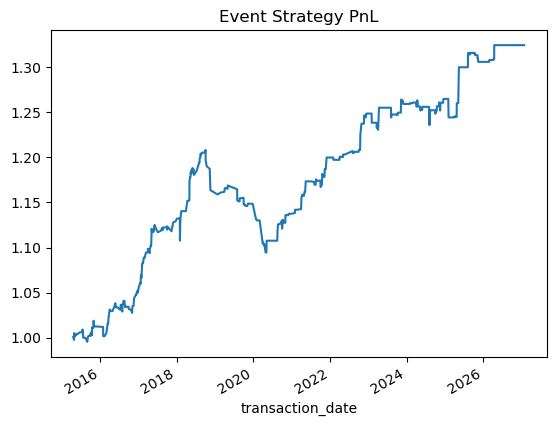

In [156]:
events = build_event_dataset(common_all, price)

X, feature_cols = build_features(events)

# 简单清洗
X["log_shares"] = X["log_shares"].fillna(0)
X["log_price"] = X["log_price"].fillna(X["log_price"].median())

model = train_model(X, feature_cols)

events = generate_positions(X, model, feature_cols)

pnl, metrics = backtest_event_strategy(events, price)

pnl.plot(title="Event Strategy PnL")

for k, v in metrics.items():
    print(f"{k}: {float(v):.4f}")